## Import Required Libraries

In [1]:

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import files
import io


## Load Dataset

In [2]:

uploaded_file = files.upload()
data_frame = pd.read_csv(io.BytesIO(uploaded_file['Housing-1.csv']))

Saving Housing-1.csv to Housing-1.csv


## Data Preprocessing


In [3]:

# Encode categorical variables
categorical_vars = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning',
    'prefarea', 'furnishingstatus'
]

label_encoder = LabelEncoder()
for var in categorical_vars:
    data_frame[var] = label_encoder.fit_transform(data_frame[var])

data_frame.dropna(inplace=True)

# Normalize features
data_frame['area'] = StandardScaler().fit_transform(data_frame[['area']])
price_scaler = StandardScaler()
data_frame['price'] = price_scaler.fit_transform(data_frame[['price']])

# Features and target variables
feature_set = data_frame.drop(columns=['price']).values
target_set = data_frame['price'].values

# Split the data into training and test sets
X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(feature_set, target_set, test_size=0.2, random_state=42)

## Define the Neural Network Structure

In [5]:
class HousePricePredictor(nn.Module):
    def __init__(self):
        super(HousePricePredictor, self).__init__()
        self.network_layers = nn.Sequential(
            nn.Linear(X_train_set.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network_layers(x)

## Train the Model

In [11]:
price_model = HousePricePredictor()
loss_function = nn.MSELoss()
optimizer = optim.Adam(price_model.parameters(), lr=0.005)

def fit_model(model, train_features, train_labels, epochs=1200):
    model.train()
    for epoch in range(epochs):
        feature_tensor = torch.tensor(train_features, dtype=torch.float32)
        label_tensor = torch.tensor(train_labels, dtype=torch.float32).view(-1, 1)

        optimizer.zero_grad()
        predictions = model(feature_tensor)
        loss_value = loss_function(predictions, label_tensor)
        loss_value.backward()
        optimizer.step()

        if (epoch + 1) % 200 == 0:
            print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss_value.item():.4f}')

fit_model(price_model, X_train_set, y_train_set)


Epoch 200/1200, Loss: 0.0378
Epoch 400/1200, Loss: 0.0146
Epoch 600/1200, Loss: 0.0080
Epoch 800/1200, Loss: 0.0065
Epoch 1000/1200, Loss: 0.0055
Epoch 1200/1200, Loss: 0.0050


## Evaluate the Model's Performance

In [12]:

price_model.eval()
with torch.no_grad():
    test_features_tensor = torch.tensor(X_test_set, dtype=torch.float32)
    test_labels_tensor = torch.tensor(y_test_set, dtype=torch.float32).view(-1, 1)

    predictions_set = price_model(test_features_tensor).numpy().flatten()
    actual_prices = price_scaler.inverse_transform(test_labels_tensor.numpy()).flatten()
    predicted_prices = price_scaler.inverse_transform(predictions_set.reshape(-1, 1)).flatten()


mse_value = mean_squared_error(actual_prices, predicted_prices)
mae_value = mean_absolute_error(actual_prices, predicted_prices)
r2_value = r2_score(actual_prices, predicted_prices)

print(f'Mean Squared Error: {mse_value:.4f}')
print(f'Mean Absolute Error: {mae_value:.4f}')
print(f'R² Score: {r2_value:.4f}')



Mean Squared Error: 1941307260928.0000
Mean Absolute Error: 1039971.8750
R² Score: 0.6159


## Plotting Results

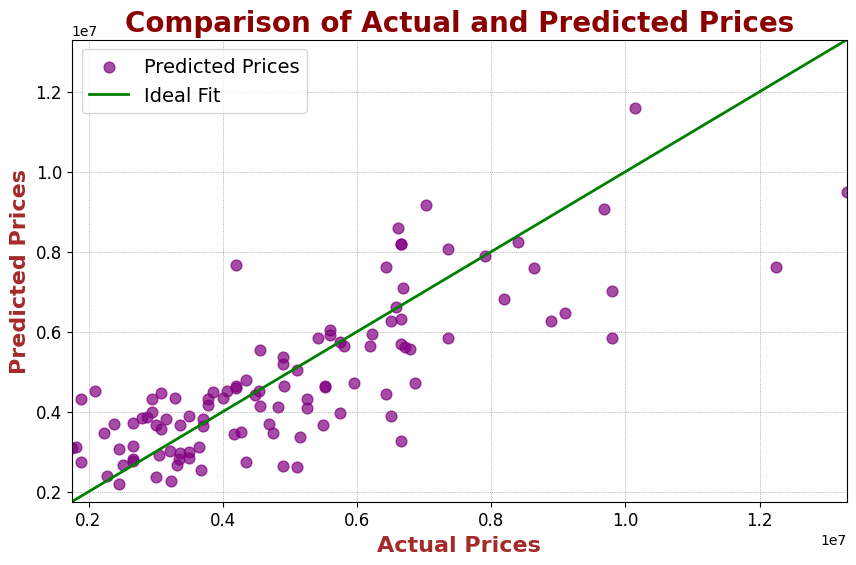

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(actual_prices, predicted_prices, color='purple', s=60, alpha=0.7, label='Predicted Prices')
plt.plot([actual_prices.min(), actual_prices.max()],
         [actual_prices.min(), actual_prices.max()],
         color='green', linestyle='-', linewidth=2, label='Ideal Fit')

plt.title('Comparison of Actual and Predicted Prices', fontsize=20, fontweight='bold', color='darkred')
plt.xlabel('Actual Prices', fontsize=16, fontweight='bold', color='brown')
plt.ylabel('Predicted Prices', fontsize=16, fontweight='bold', color='brown')
plt.legend(fontsize=14)
plt.grid(color='gray', linestyle=':', linewidth=0.5)
plt.xlim(actual_prices.min(), actual_prices.max())
plt.ylim(actual_prices.min(), actual_prices.max())
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()